# ASL Gesture Recognition — MLP Training
**Run this in WSL Ubuntu with asl_env activated**

```bash
cd /mnt/c/HiASL_BSE_FYP_2026/asl-gesture-recognition-model
source asl_env/bin/activate
jupyter notebook
```

### What this notebook does:
1. Load cleaned dataset (X_clean.npy, y_clean.npy)
2. Encode labels and split train/validation
3. Build MLP model (mirrors reference architecture)
4. Train with EarlyStopping + ReduceLROnPlateau
5. Plot training curves
6. Evaluate and show per-class accuracy
7. Save model as mlp_model.h5 and label encoder

## 1. Setup & Imports

In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import pickle

# ── Configuration ─────────────────────────────────────────────
BASE_DIR     = '/mnt/c/HiASL_BSE_FYP_2026/asl-gesture-recognition-model/static'
MODEL_DIR    = '/mnt/c/HiASL_BSE_FYP_2026/asl-gesture-recognition-model/static/model'
RANDOM_SEED  = 42
TEST_SIZE    = 0.2      # 80% train, 20% validation
BATCH_SIZE   = 32
MAX_EPOCHS   = 200

os.makedirs(MODEL_DIR, exist_ok=True)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print(f'TensorFlow version: {tf.__version__}')
print(f'Base directory: {BASE_DIR}')
print(f'Model will be saved to: {MODEL_DIR}')

I0000 00:00:1784268104.797585   11175 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784268104.825931   11175 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1784268106.089778   11175 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1784268121.300566   11175 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

TensorFlow version: 2.21.0
Base directory: /mnt/c/HiASL_BSE_FYP_2026/asl-gesture-recognition-model/static
Model will be saved to: /mnt/c/HiASL_BSE_FYP_2026/asl-gesture-recognition-model/static/model


## 2. Load Cleaned Dataset

In [2]:
X = np.load(os.path.join(BASE_DIR, 'X_clean.npy'))
y = np.load(os.path.join(BASE_DIR, 'y_clean.npy'))

print(f'X shape: {X.shape}')    # (19812, 63)
print(f'y shape: {y.shape}')    # (19812,)
print(f'Classes: {np.unique(y)}')
print(f'Total classes: {len(np.unique(y))}')
print(f'Sample counts per class:')
unique, counts = np.unique(y, return_counts=True)
for cls, cnt in zip(unique, counts):
    print(f'  {cls}: {cnt}')

X shape: (19812, 63)
y shape: (19812,)
Classes: ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9' 'A' 'B' 'C' 'D' 'E' 'F' 'G' 'H'
 'I' 'J' 'K' 'L' 'M' 'N' 'O' 'P' 'Q' 'R' 'S' 'T' 'U' 'V' 'W' 'X' 'Y' 'Z']
Total classes: 36
Sample counts per class:
  0: 442
  1: 600
  2: 600
  3: 600
  4: 600
  5: 600
  6: 600
  7: 600
  8: 600
  9: 600
  A: 331
  B: 600
  C: 296
  D: 600
  E: 556
  F: 600
  G: 600
  H: 600
  I: 600
  J: 600
  K: 600
  L: 600
  M: 600
  N: 448
  O: 225
  P: 600
  Q: 469
  R: 600
  S: 526
  T: 319
  U: 600
  V: 600
  W: 600
  X: 600
  Y: 600
  Z: 600


## 3. Encode Labels & Train/Val Split

In [3]:
# Encode string labels to integers
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)          # e.g. 'A' -> 0, 'B' -> 1 ...
num_classes = len(label_encoder.classes_)

# One-hot encode for categorical crossentropy
y_onehot = to_categorical(y_encoded, num_classes=num_classes)

# Train / validation split — stratified to keep class balance
X_train, X_val, y_train, y_val = train_test_split(
    X, y_onehot,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    stratify=y_encoded       # ensures each class is proportionally represented
)

print(f'Label encoder classes: {label_encoder.classes_}')
print(f'Number of classes: {num_classes}')
print(f'\nTrain set: {X_train.shape[0]} samples')
print(f'Val set:   {X_val.shape[0]} samples')
print(f'\nX_train shape: {X_train.shape}')   # (N, 63)
print(f'y_train shape: {y_train.shape}')    # (N, 36)

# Save label encoder for inference
encoder_path = os.path.join(MODEL_DIR, 'label_encoder.pkl')
with open(encoder_path, 'wb') as f:
    pickle.dump(label_encoder, f)
print(f'\nLabel encoder saved to: {encoder_path}')

Label encoder classes: ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9' 'A' 'B' 'C' 'D' 'E' 'F' 'G' 'H'
 'I' 'J' 'K' 'L' 'M' 'N' 'O' 'P' 'Q' 'R' 'S' 'T' 'U' 'V' 'W' 'X' 'Y' 'Z']
Number of classes: 36

Train set: 15849 samples
Val set:   3963 samples

X_train shape: (15849, 63)
y_train shape: (15849, 36)

Label encoder saved to: /mnt/c/HiASL_BSE_FYP_2026/asl-gesture-recognition-model/static/model/label_encoder.pkl


## 4. Build MLP Model
Architecture mirrors the reference Malaysian Sign Language MLP,
adapted for 1 hand (63 features) and 36 classes (A-Z + 0-9).

In [4]:
model = Sequential([
    # Input normalization — stabilizes training (from reference architecture)
    BatchNormalization(input_shape=(63,)),

    # Hidden layer 1
    Dense(128, activation='relu'),
    Dropout(0.3),

    # Hidden layer 2
    Dense(64, activation='relu'),
    Dropout(0.3),

    # Output — 36 classes softmax
    Dense(num_classes, activation='softmax')
], name='asl_mlp')

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/mnt/c/HiASL_BSE_FYP_2026/asl-gesture-recognition-model/asl_env/lib/python3.11/site-packages/keras/src/layers/normalization/batch_normalization.py:181: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
E0000 00:00:1784268133.745454   11175 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "asl_mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization             │ (None, 63)             │           252 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 36)             │         2,340 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,040 (74.38 KB)

 Trainable params: 18,914 (73.88 KB)

 Non-trainable params: 126 (504.00 B)

## 5. Define Callbacks
Identical to reference architecture callbacks.

In [5]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=7,
    min_lr=1e-6,
    verbose=1
)

print('Callbacks set:')
print(f'  EarlyStopping: patience=20, restore_best_weights=True')
print(f'  ReduceLROnPlateau: factor=0.5, patience=7, min_lr=1e-6')

Callbacks set:
  EarlyStopping: patience=20, restore_best_weights=True
  ReduceLROnPlateau: factor=0.5, patience=7, min_lr=1e-6


## 6. Train Model

In [6]:
print('Starting training...')
print(f'Max epochs: {MAX_EPOCHS} (EarlyStopping will stop early if val_loss plateaus)')
print('=' * 60)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

print('=' * 60)
print(f'Training complete!')
print(f'Stopped at epoch: {len(history.history["loss"])}')
print(f'Best val_loss: {min(history.history["val_loss"]):.4f}')
print(f'Best val_accuracy: {max(history.history["val_accuracy"]):.4f}')

Starting training...
Max epochs: 200 (EarlyStopping will stop early if val_loss plateaus)
Epoch 1/200
496/496 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5326 - loss: 1.5716 - val_accuracy: 0.9134 - val_loss: 0.3299 - learning_rate: 0.0010
Epoch 2/200
496/496 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8109 - loss: 0.5321 - val_accuracy: 0.9586 - val_loss: 0.1490 - learning_rate: 0.0010
Epoch 3/200
496/496 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8713 - loss: 0.3513 - val_accuracy: 0.9697 - val_loss: 0.0959 - learning_rate: 0.0010
Epoch 4/200
496/496 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8970 - loss: 0.2742 - val_accuracy: 0.9748 - val_loss: 0.0777 - learning_rate: 0.0010
Epoch 5/200
496/496 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9146 - loss: 0.2301 - val_accuracy: 0.9793 - val_loss: 0.0655 - learning_rate: 0.0010
Epoch 6/200
496/496 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9260 - loss: 0.1984 - val_accuracy: 0.9859 - val_loss: 0.0536 - learning_rate:

## 7. Plot Training Curves

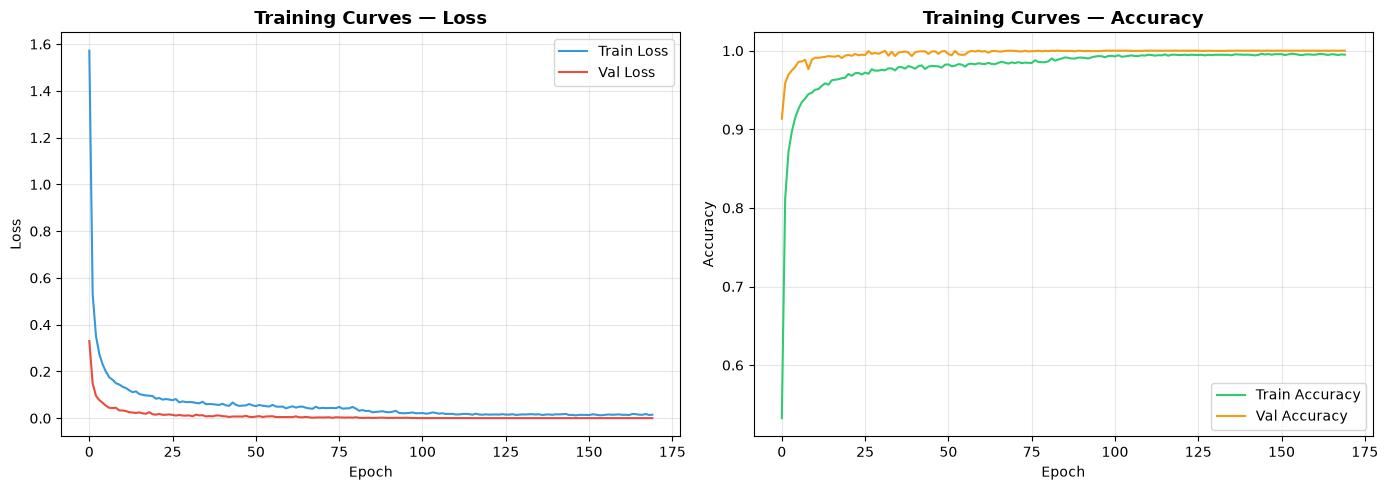

Training curves saved to: /mnt/c/HiASL_BSE_FYP_2026/asl-gesture-recognition-model/static/model/training_curves.png


In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax1.plot(history.history['loss'],     label='Train Loss', color='#3498db')
ax1.plot(history.history['val_loss'], label='Val Loss',   color='#e74c3c')
ax1.set_title('Training Curves — Loss', fontsize=13, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(alpha=0.3)

# Accuracy
ax2.plot(history.history['accuracy'],     label='Train Accuracy', color='#2ecc71')
ax2.plot(history.history['val_accuracy'], label='Val Accuracy',   color='#f39c12')
ax2.set_title('Training Curves — Accuracy', fontsize=13, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plot_path = os.path.join(MODEL_DIR, 'training_curves.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Training curves saved to: {plot_path}')

## 8. Evaluate Model

In [8]:
# Overall evaluation
val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
print(f'=== FINAL EVALUATION ===')
print(f'Validation Loss:     {val_loss:.4f}')
print(f'Validation Accuracy: {val_acc:.4f} ({val_acc*100:.2f}%)')

# Per-class report
y_pred        = model.predict(X_val, verbose=0)
y_pred_labels = label_encoder.inverse_transform(np.argmax(y_pred, axis=1))
y_true_labels = label_encoder.inverse_transform(np.argmax(y_val,  axis=1))

print(f'\n=== PER-CLASS REPORT ===')
print(classification_report(y_true_labels, y_pred_labels,
                             target_names=label_encoder.classes_))

=== FINAL EVALUATION ===
Validation Loss:     0.0005
Validation Accuracy: 1.0000 (100.00%)

=== PER-CLASS REPORT ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        89
           1       1.00      1.00      1.00       120
           2       1.00      1.00      1.00       120
           3       1.00      1.00      1.00       120
           4       1.00      1.00      1.00       120
           5       1.00      1.00      1.00       120
           6       1.00      1.00      1.00       120
           7       1.00      1.00      1.00       120
           8       1.00      1.00      1.00       120
           9       1.00      1.00      1.00       120
           A       1.00      1.00      1.00        66
           B       1.00      1.00      1.00       120
           C       1.00      1.00      1.00        59
           D       1.00      1.00      1.00       120
           E       1.00      1.00      1.00       111
           F      

## 9. Confusion Matrix

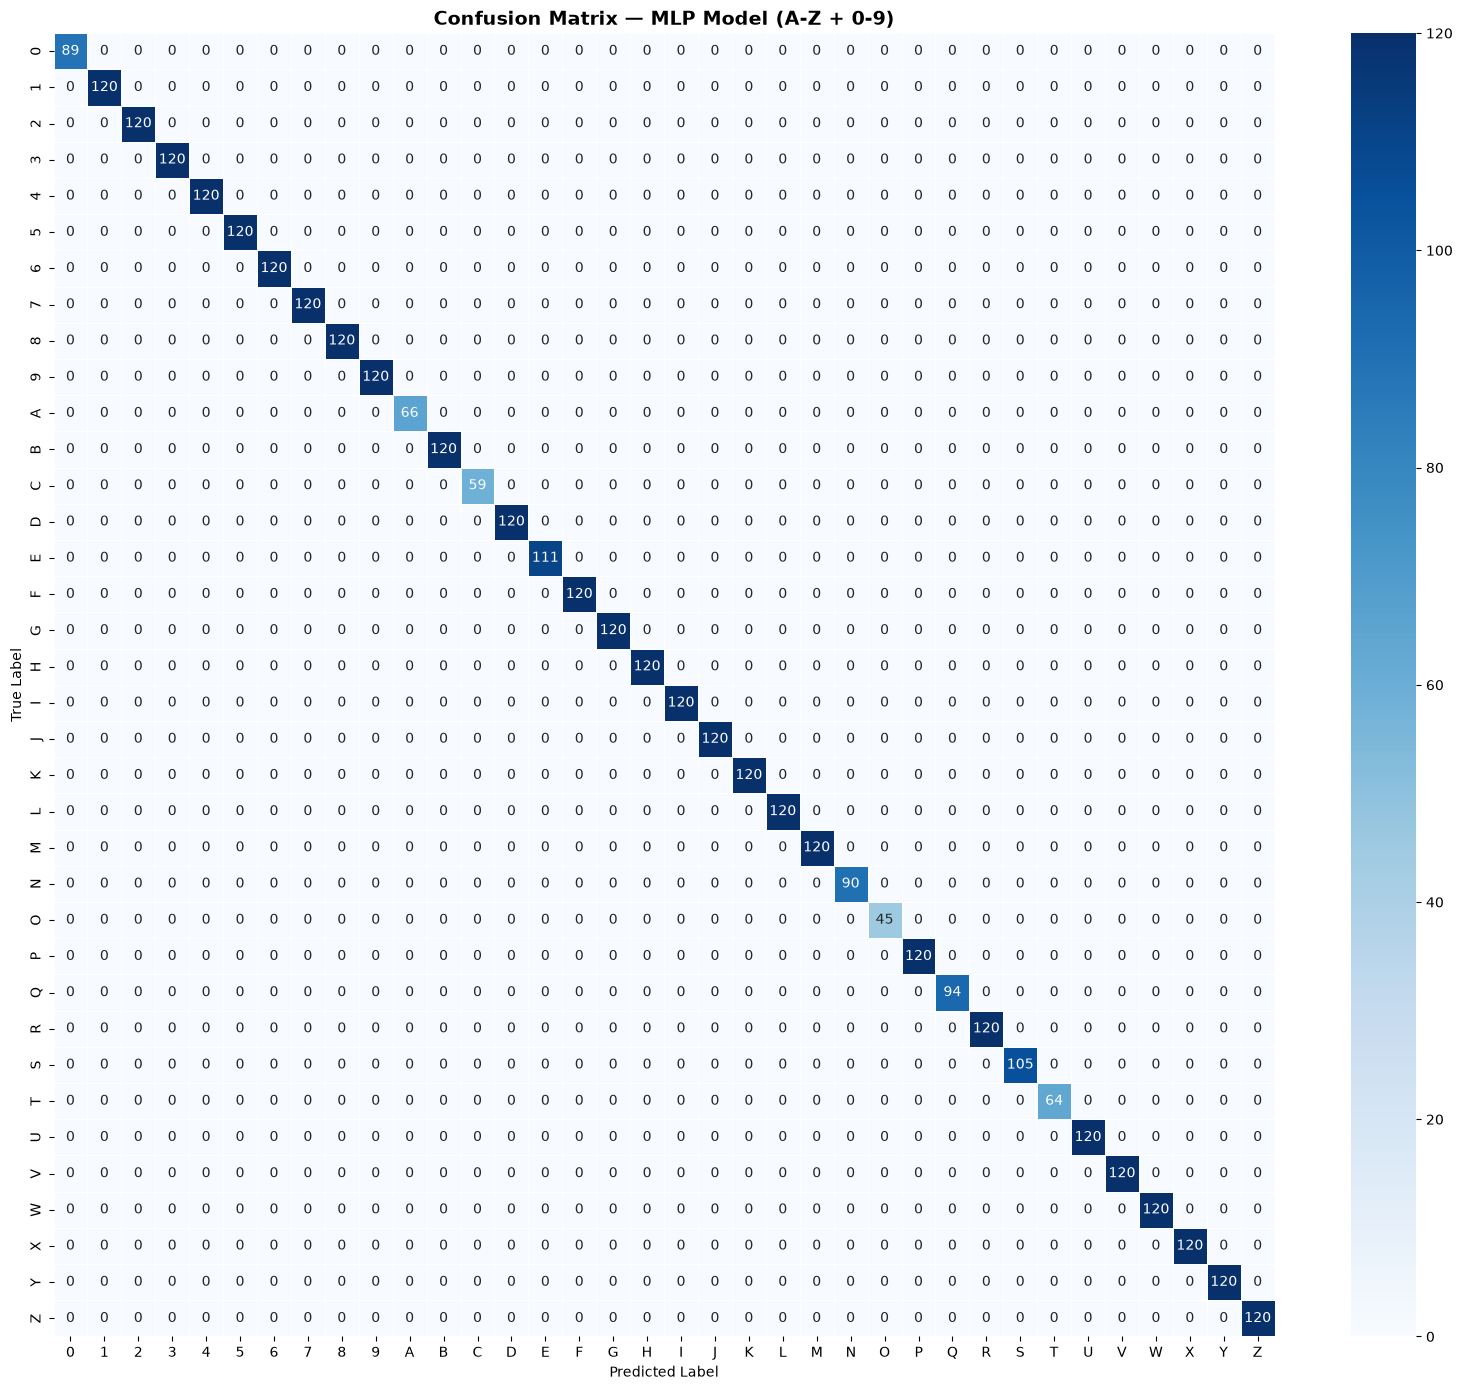

Confusion matrix saved to: /mnt/c/HiASL_BSE_FYP_2026/asl-gesture-recognition-model/static/model/confusion_matrix.png

=== CLASSES WITH ACCURACY < 80% ===
  All classes >= 80% accuracy!


In [9]:
cm = confusion_matrix(y_true_labels, y_pred_labels,
                      labels=label_encoder.classes_)

plt.figure(figsize=(16, 14))
sns.heatmap(
    cm,
    annot=True, fmt='d',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_,
    cmap='Blues',
    linewidths=0.5
)
plt.title('Confusion Matrix — MLP Model (A-Z + 0-9)', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
cm_path = os.path.join(MODEL_DIR, 'confusion_matrix.png')
plt.savefig(cm_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Confusion matrix saved to: {cm_path}')

# Flag low accuracy classes
print('\n=== CLASSES WITH ACCURACY < 80% ===')
low_acc = []
for i, cls in enumerate(label_encoder.classes_):
    if cm[i].sum() > 0:
        acc = cm[i, i] / cm[i].sum()
        if acc < 0.8:
            low_acc.append((cls, acc))
            print(f'  {cls}: {acc*100:.1f}%')
if not low_acc:
    print('  All classes >= 80% accuracy!')

## 10. Save Model

In [10]:
# Save model
model_path = os.path.join(MODEL_DIR, 'mlp_model.h5')
model.save(model_path)

print('=== MODEL SAVED ===')
print(f'Model:         {model_path}')
print(f'Label encoder: {encoder_path}')
print(f'Training plot: {os.path.join(MODEL_DIR, "training_curves.png")}')
print(f'Confusion matrix: {os.path.join(MODEL_DIR, "confusion_matrix.png")}')
print(f'\nModel summary:')
print(f'  Input shape:  (63,)')
print(f'  Output shape: ({num_classes},)')
print(f'  Classes: {list(label_encoder.classes_)}')
print(f'\nTo load model for inference:')
print(f'  model = keras.models.load_model("{model_path}")')
print(f'  with open("{encoder_path}", "rb") as f:')
print(f'      label_encoder = pickle.load(f)')

=== MODEL SAVED ===
Model:         /mnt/c/HiASL_BSE_FYP_2026/asl-gesture-recognition-model/static/model/mlp_model.h5
Label encoder: /mnt/c/HiASL_BSE_FYP_2026/asl-gesture-recognition-model/static/model/label_encoder.pkl
Training plot: /mnt/c/HiASL_BSE_FYP_2026/asl-gesture-recognition-model/static/model/training_curves.png
Confusion matrix: /mnt/c/HiASL_BSE_FYP_2026/asl-gesture-recognition-model/static/model/confusion_matrix.png

Model summary:
  Input shape:  (63,)
  Output shape: (36,)
  Classes: [np.str_('0'), np.str_('1'), np.str_('2'), np.str_('3'), np.str_('4'), np.str_('5'), np.str_('6'), np.str_('7'), np.str_('8'), np.str_('9'), np.str_('A'), np.str_('B'), np.str_('C'), np.str_('D'), np.str_('E'), np.str_('F'), np.str_('G'), np.str_('H'), np.str_('I'), np.str_('J'), np.str_('K'), np.str_('L'), np.str_('M'), np.str_('N'), np.str_('O'), np.str_('P'), np.str_('Q'), np.str_('R'), np.str_('S'), np.str_('T'), np.str_('U'), np.str_('V'), np.str_('W'), np.str_('X'), np.str_('Y'), np.str_